 ## Overview
Anxiety is a complex mental health condition that affects millions of people worldwide. It is influenced by a variety of factors, ranging from daily lifestyle habits (like diet and sleep) to biological history and sudden external stressors.

## Objective
The goal of this project is to explore a dataset of ~12,000 individuals to identify the key drivers of anxiety. By performing Exploratory Data Analysis (EDA) and applying Machine Learning, we aim to:

* **Understand the "tipping points"** where anxiety shifts from mild to severe.
* **Identify lifestyle factors** (e.g., Diet, Therapy, Sleep) that have the strongest correlation with anxiety levels.
* **Build a predictive model** to accurately classify an individual's anxiety level based on their habits and history.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("anxiety_dataset.csv")
df.head()

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-5)
0,39,Other,Freelancer,7.7,3.1,353,19,Yes,Yes,6,58,18,1,No,Yes,3,Yes,1,2
1,53,Other,Musician,7.4,1.9,70,9,Yes,Yes,2,92,26,1,No,No,1,No,5,1
2,44,Male,Lawyer,5.1,1.9,480,18,Yes,No,9,98,25,4,Yes,No,8,No,2,5
3,49,Other,Freelancer,4.6,1.3,491,9,Yes,Yes,9,108,21,3,No,Yes,5,Yes,4,5
4,39,Other,Scientist,6.1,2.0,566,2,No,Yes,6,64,15,2,No,No,2,No,7,3


In [3]:
print(df['Anxiety Level (1-5)'].value_counts())

Anxiety Level (1-5)
3    2713
2    2589
4    2437
1    2306
5    2248
Name: count, dtype: int64


In [4]:
df.shape

(12293, 19)

In [5]:
df.describe()

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Therapy Sessions (per month),Diet Quality (1-10),Anxiety Level (1-5)
count,12293.000000,12293.000000,12293.000000,12293.000000,12293.000000,12293.000000,12293.000000,12293.000000,12293.000000,12293.000000,12293.000000,12293.000000
mean,38.962662,6.064289,2.352794,332.490198,10.242577,6.355568,94.627430,21.835842,3.140486,3.551045,4.525096,2.978199
std,12.446906,1.515566,1.533202,150.608850,5.466154,2.777589,17.091824,4.928638,1.339723,2.738839,2.833908,1.374899
min,18.000000,3.000000,0.000000,0.000000,0.000000,1.000000,55.000000,12.000000,1.000000,0.000000,1.000000,1.000000
25%,29.000000,4.800000,1.100000,217.000000,6.000000,5.000000,82.000000,18.000000,2.000000,1.000000,2.000000,2.000000
50%,38.000000,6.000000,2.200000,329.000000,10.000000,7.000000,97.000000,22.000000,3.000000,3.000000,4.000000,3.000000
75%,48.000000,7.200000,3.400000,457.000000,15.000000,8.000000,109.000000,26.000000,4.000000,6.000000,7.000000,4.000000
max,64.000000,12.000000,8.900000,599.000000,19.000000,10.000000,124.000000,29.000000,5.000000,12.000000,10.000000,5.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12293 entries, 0 to 12292
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                12293 non-null  int64  
 1   Gender                             12293 non-null  object 
 2   Occupation                         12293 non-null  object 
 3   Sleep Hours                        12293 non-null  float64
 4   Physical Activity (hrs/week)       12293 non-null  float64
 5   Caffeine Intake (mg/day)           12293 non-null  int64  
 6   Alcohol Consumption (drinks/week)  12293 non-null  int64  
 7   Smoking                            12293 non-null  object 
 8   Family History of Anxiety          12293 non-null  object 
 9   Stress Level (1-10)                12293 non-null  int64  
 10  Heart Rate (bpm)                   12293 non-null  int64  
 11  Breathing Rate (breaths/min)       12293 non-null  int

In [7]:
df.isnull().sum()

Age                                  0
Gender                               0
Occupation                           0
Sleep Hours                          0
Physical Activity (hrs/week)         0
Caffeine Intake (mg/day)             0
Alcohol Consumption (drinks/week)    0
Smoking                              0
Family History of Anxiety            0
Stress Level (1-10)                  0
Heart Rate (bpm)                     0
Breathing Rate (breaths/min)         0
Sweating Level (1-5)                 0
Dizziness                            0
Medication                           0
Therapy Sessions (per month)         0
Recent Major Life Event              0
Diet Quality (1-10)                  0
Anxiety Level (1-5)                  0
dtype: int64

In [8]:
import seaborn as sns

In [9]:
import matplotlib.pyplot as plt

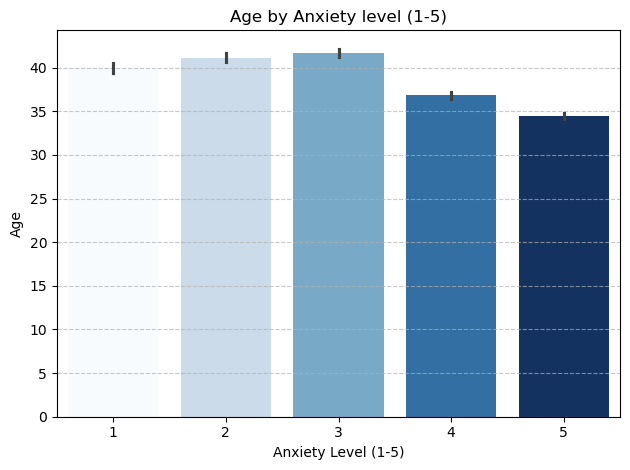

In [10]:
sns.barplot(x="Anxiety Level (1-5)",y="Age",data=df,palette="Blues",hue="Anxiety Level (1-5)",legend=False)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("Age by Anxiety level (1-5)")
plt.tight_layout()
plt.show()

The bar plot shows a relationship where younger age correlates with higher anxiety levels in this dataset. For Anxiety level between 1 to 3, the average age remains consistent at approximately 40 years.As we move to severe anxiety (Levels 4 and 5), the average age drops to approximately 35 years.

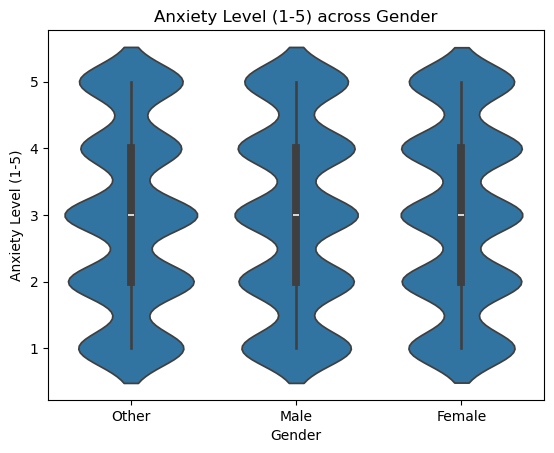

In [11]:
sns.violinplot(y="Anxiety Level (1-5)",x="Gender",data=df)
plt.title("Anxiety Level (1-5) across Gender")
plt.show()

In [12]:
df.groupby('Gender')["Anxiety Level (1-5)"].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,4247.0,2.998823,1.376318,1.0,2.0,3.0,4.0,5.0
Male,4140.0,2.982609,1.381263,1.0,2.0,3.0,4.0,5.0
Other,3906.0,2.951101,1.366478,1.0,2.0,3.0,4.0,5.0


Anxiety levels are almost the same across all gender groups. The means are all concentrated around 3, with differences of less than 0.03, and the overall range (1–5) is identical. This shows that gender does not have a meaningful impact on anxiety levels in this dataset

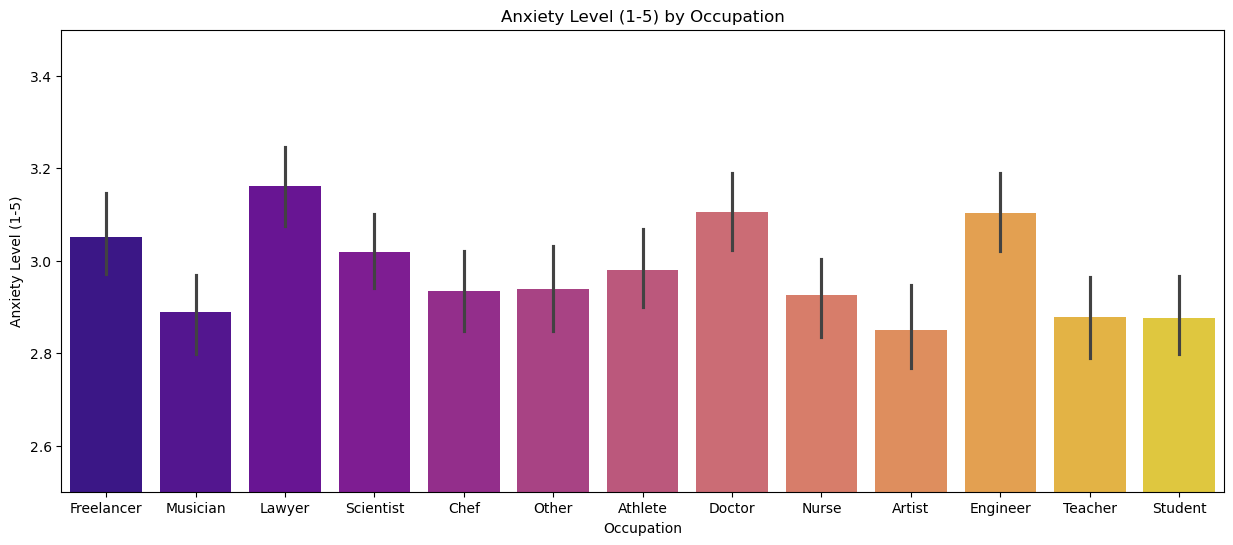

In [13]:
plt.figure(figsize=(15,6))
sns.barplot(x="Occupation", y="Anxiety Level (1-5)", data=df, palette="plasma",hue="Occupation",legend=False)
plt.ylim(2.5, 3.5) 
plt.title("Anxiety Level (1-5) by Occupation")
plt.show()

In [14]:
df.groupby('Occupation')['Anxiety Level (1-5)'].describe()

,count,mean,std,min,25%,50%,75%,max
Occupation,,,,,,,,
Artist,954.0,2.850105,1.391612,1.0,2.0,3.0,4.0,5.0
Athlete,939.0,2.980831,1.379740,1.0,2.0,3.0,4.0,5.0
Chef,952.0,2.934874,1.382618,1.0,2.0,3.0,4.0,5.0
Doctor,961.0,3.106139,1.365182,1.0,2.0,3.0,4.0,5.0
Engineer,985.0,3.102538,1.309224,1.0,2.0,3.0,4.0,5.0
Freelancer,934.0,3.050321,1.395382,1.0,2.0,3.0,4.0,5.0
Lawyer,928.0,3.162716,1.321317,1.0,2.0,3.0,4.0,5.0
Musician,967.0,2.888314,1.415654,1.0,2.0,3.0,4.0,5.0
Nurse,940.0,2.926596,1.362019,1.0,2.0,3.0,4.0,5.0


The bar graph shows that the occupations like Lawyers (3.16), Doctors (3.11), and Engineers (3.10) have slighltly higher anxiety level than other occupations.

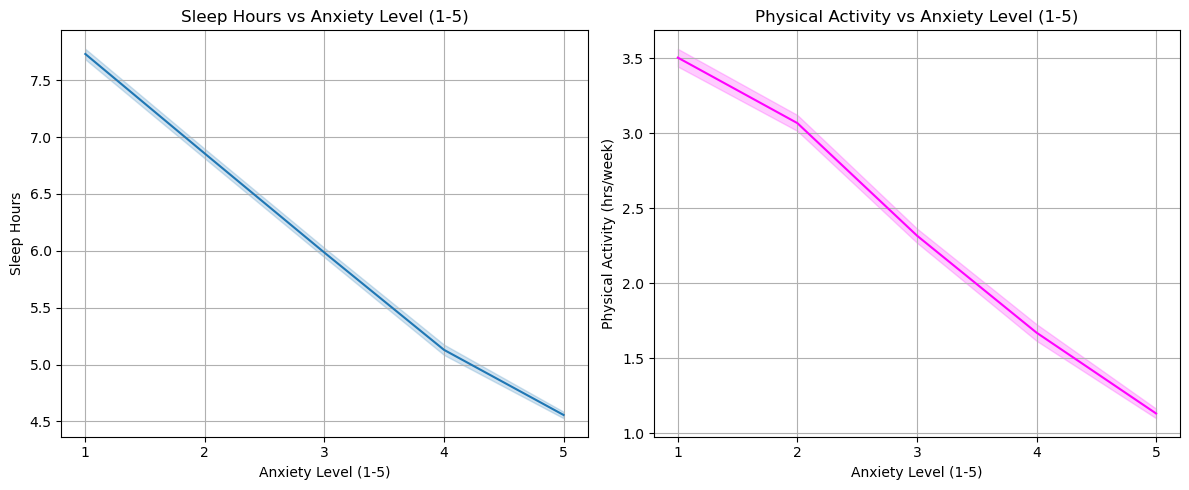

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  

# Plot 1
sns.lineplot(x="Anxiety Level (1-5)", y="Sleep Hours",data=df, ax=axes[0])
axes[0].set_xticks([1,2,3,4,5])
axes[0].grid(True)
axes[0].set_title("Sleep Hours vs Anxiety Level (1-5)")

# Plot 2
sns.lineplot(x="Anxiety Level (1-5)", y="Physical Activity (hrs/week)", data=df, color="magenta",ax=axes[1])
axes[1].set_xticks([1,2,3,4,5])
axes[1].grid(True)
axes[1].set_title("Physical Activity vs Anxiety Level (1-5)")

plt.tight_layout()
plt.show()

The line plot shows a strong negative relationship between sleep duration and anxiety levels. Individuals in the low anxiety category (Level 1) maintain a healthy sleep baseline, averaging nearly 8 hours per night. As anxiety increases to Level 3, sleep decreases to approximately 6 hours, further dropping to a minimum of 4.5–5 hours for the highest anxiety levels (4–5).

The line plot reveals a significant inverse relationship between physical activity and anxiety, particularly at the higher levels. For individuals in the low to moderate anxiety categories (Levels 1–3), physical activity remains relatively stable, averaging approximately 3.0 to 3.5 hours per week. However, for those with severe anxiety (Levels 4–5), there is a sharp decline, with activity levels dropping significantly to a minimum of 1.1–1.5 hours per week

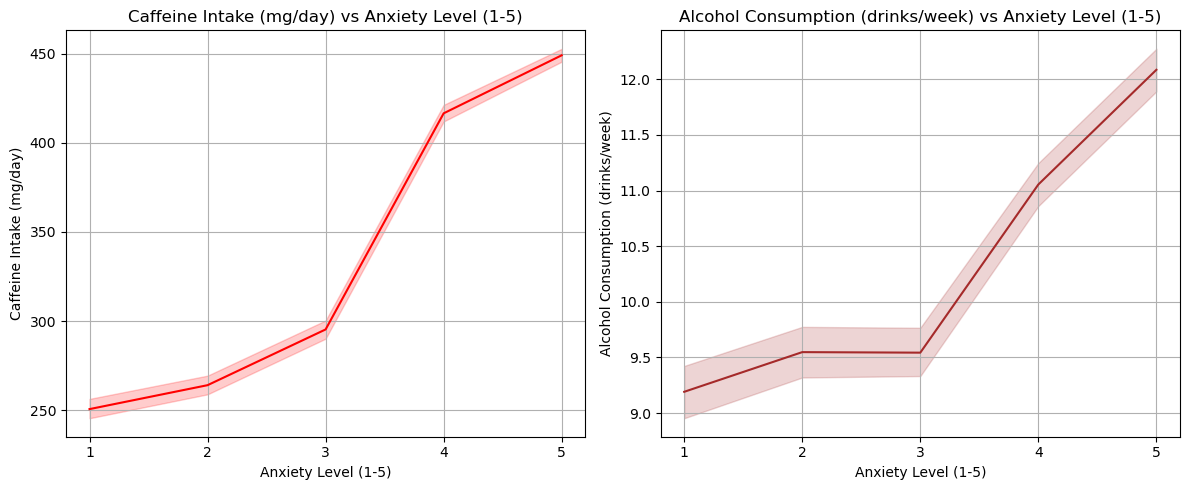

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  

# Plot 1
sns.lineplot(x="Anxiety Level (1-5)", y="Caffeine Intake (mg/day)",data=df,color="red",ax=axes[0])
axes[0].set_xticks([1,2,3,4,5])
axes[0].grid(True)
axes[0].set_title("Caffeine Intake (mg/day) vs Anxiety Level (1-5)")

# Plot 2
sns.lineplot(x="Anxiety Level (1-5)", y="Alcohol Consumption (drinks/week)", data=df, color="brown",ax=axes[1])
axes[1].set_xticks([1,2,3,4,5])
axes[1].grid(True)
axes[1].set_title("Alcohol Consumption (drinks/week) vs Anxiety Level (1-5)")

plt.tight_layout()
plt.show()

The line graph shows a clear positive relationship between caffeine intake and anxiety levels. For individuals with anxiety levels between 1 and 3, caffeine intake remains relatively low (under 290 mg/day). However, there is a sharp spike at Level 4, where intake jumps to approximately 430 mg/day, remaining high for Level 5.

The line graph shows is a positive correlation between alcohol consumption and anxiety, though the trend is more gradual. For the anxiety range of 1–3, the average alcohol consumption is approximately 9.3–9.6 drinks per week. For the highest anxiety levels (4–5),the average alcohol consumption is approximately 9.6–12.1 drinks per week.

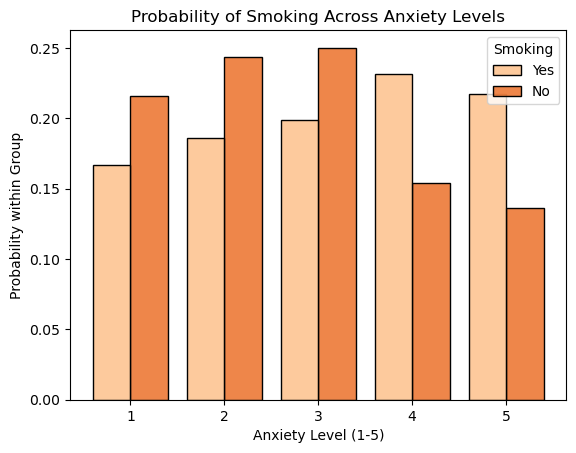

In [17]:
sns.histplot(data=df, hue="Smoking", x="Anxiety Level (1-5)",discrete=True, 
             multiple="dodge",shrink=.8, stat="probability", common_norm=False,palette="Oranges")

plt.xticks([1, 2, 3, 4, 5]) 

plt.title("Probability of Smoking Across Anxiety Levels")
plt.ylabel("Probability within Group")
plt.show()

The plot shows that smoking habits shift drastically as anxiety becomes severe. For mild to moderate anxiety (Levels 1–3), most people in the study do not smoke. However, at Anxiety Level 4 and 5, there is a clear reversal where the probability of being a smoker exceeds that of being a non-smoker, suggesting a strong link between peak anxiety and smoking.

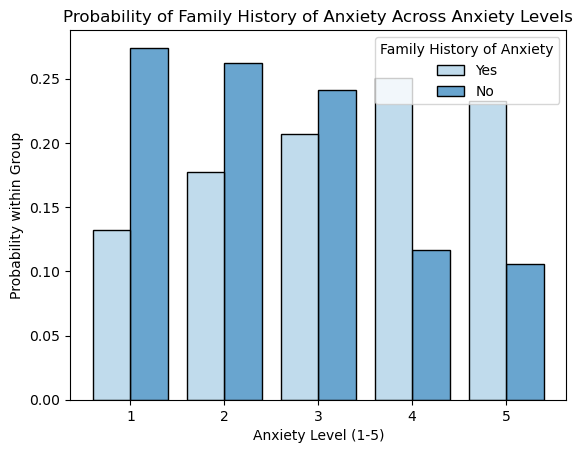

In [18]:
sns.histplot(data=df, hue='Family History of Anxiety', x="Anxiety Level (1-5)",discrete=True, 
             multiple="dodge",shrink=.8, stat="probability", common_norm=False,palette="Blues")

plt.xticks([1, 2, 3, 4, 5]) 

plt.title("Probability of Family History of Anxiety Across Anxiety Levels")
plt.ylabel("Probability within Group")
plt.show()

The graph shows that a family history of anxiety becomes a much stronger factor as anxiety severity increases. For individuals at Levels 1, 2, and 3 most do not report a family history. However, at Anxiety Level 4 and 5, individuals with a family history of anxiety outnumber those who do not, and there is a significant difference between the 'Yes' and 'No' groups

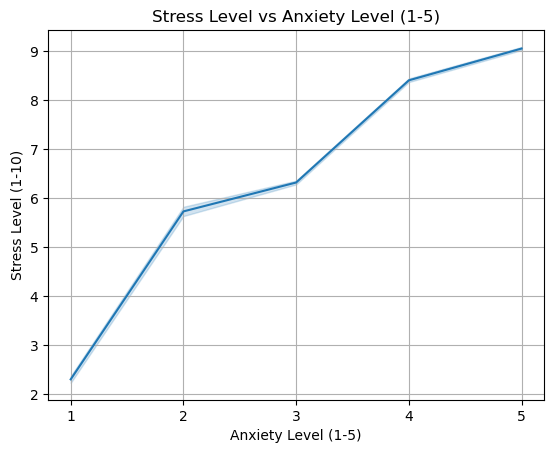

In [19]:
sns.lineplot(y="Stress Level (1-10)",x='Anxiety Level (1-5)',data=df)
plt.xticks([1,2,3,4,5])
plt.title("Stress Level vs Anxiety Level (1-5)")
plt.grid()
plt.show()

The graph shows a clear link between stress level and anxiety as  stress goes up, anxiety follows. For low anxiety (Levels 1–2), stress stays manageable, usually scoring below 6. At Level 3, the stress score stays almost the same as Level 2, showing a temporary pause before the big jump in higher levels. However, for high anxiety (Levels 4–5), stress scores jump to 9 or 10. This proves that high daily stress is a major trigger for severe anxiety.

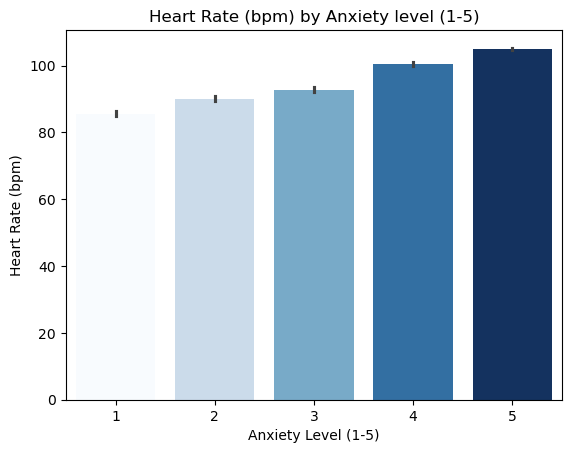

In [20]:
sns.barplot(x="Anxiety Level (1-5)", y="Heart Rate (bpm)", data=df, hue="Anxiety Level (1-5)", palette="Blues", legend=False)
plt.title("Heart Rate (bpm) by Anxiety level (1-5)")
plt.show()

The bar plot shows steady positive correlation between Heart Rate and Anxiety Level. While a typical healthy heart rate ranges from 60–100 bpm, the data shows a clear shift across categories.Low Anxiety levels 1 to 3 have approximately heart rate between range 82-85 bpm. High Anxiety(Levels 4–5) Individuals consistently show heart rates above 100 bpm.

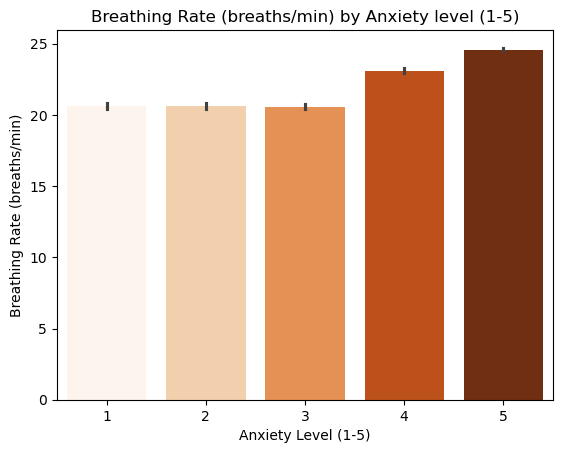

In [21]:
sns.barplot(x="Anxiety Level (1-5)",y="Breathing Rate (breaths/min)",data=df,palette="Oranges",hue="Anxiety Level (1-5)",legend=False)
plt.title("Breathing Rate (breaths/min) by Anxiety level (1-5)")
plt.show()

A normal resting respiratory rate for a healthy adult is 12 to 20 breaths per minute. 
As for anxiety level between 1 to 3 breathing rate is remains stable at a baseline of approximately 20 breaths/min. For higher level (4 and 5) the breathing rate ranges between 22-25 breaths/min. 

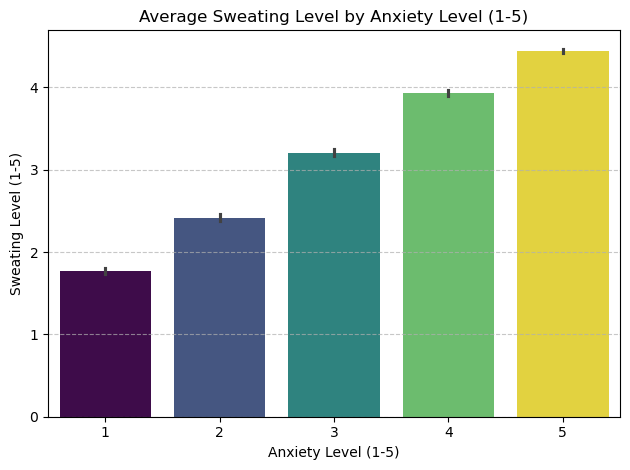

In [22]:
sns.barplot(x="Anxiety Level (1-5)", y="Sweating Level (1-5)", data=df, hue="Anxiety Level (1-5)", palette="viridis", legend=False)
plt.title("Average Sweating Level by Anxiety Level (1-5)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The bar plot shows a clear positive correlation between sweating intensity and anxiety levels. The bar plot shows a clear positive correlation between sweating intensity and anxiety levels. For anxiety level (1-3) the average sweating level remains stable at approximately 3. For higher anxiety level 4 and 5 the average sweating level is approximately between range 3.9 to 4.5. 

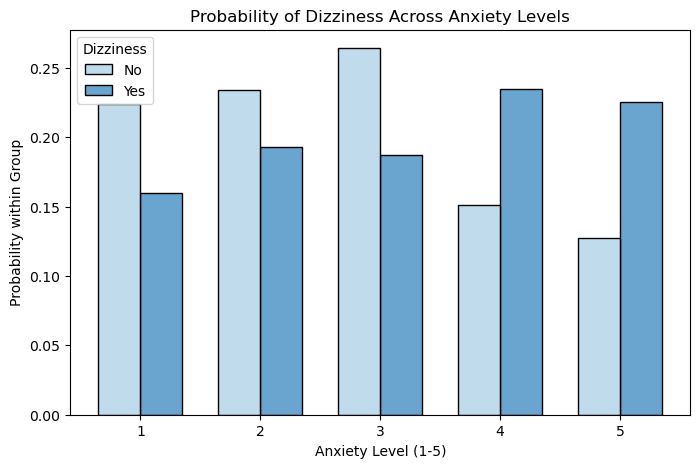

In [23]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Anxiety Level (1-5)", hue="Dizziness", 
             multiple="dodge",shrink=0.7, stat="probability",discrete=True,
             common_norm=False, palette="Blues")

plt.xticks([1, 2, 3, 4, 5]) 

plt.title("Probability of Dizziness Across Anxiety Levels")
plt.ylabel("Probability within Group")
plt.show()

The probability distribution indicates that for individuals with low to moderate anxiety (Levels 1–3), the likelihood of experiencing dizziness is significantly lower than those who do not experience it but for higher anxiety levels (4 and 5)  Individuals experienced dizziness are more than to those who did not experience dizziness.

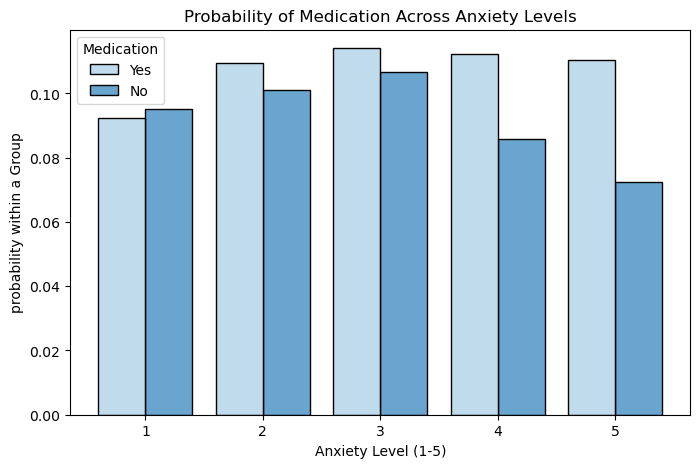

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Anxiety Level (1-5)",hue='Medication',multiple="dodge",
             palette="Blues",stat="probability",shrink=0.8,discrete=True)
plt.xticks([1,2,3,4,5])
plt.ylabel("probability within a Group")
plt.title("Probability of Medication Across Anxiety Levels")
plt.show()

From graph only for Anxiety level 1 is the only group where majority of individuals do not take medication. Level 2 is serves as a thereshold for Medication. For level 2 and 3 the "yes" group is slightly higher than the "No" group. For Level 4 and 5 the there is a significant difference between "Yes" and "No" group giving an idea that individuals took medication for higher anxiety levels rather than forgoing.

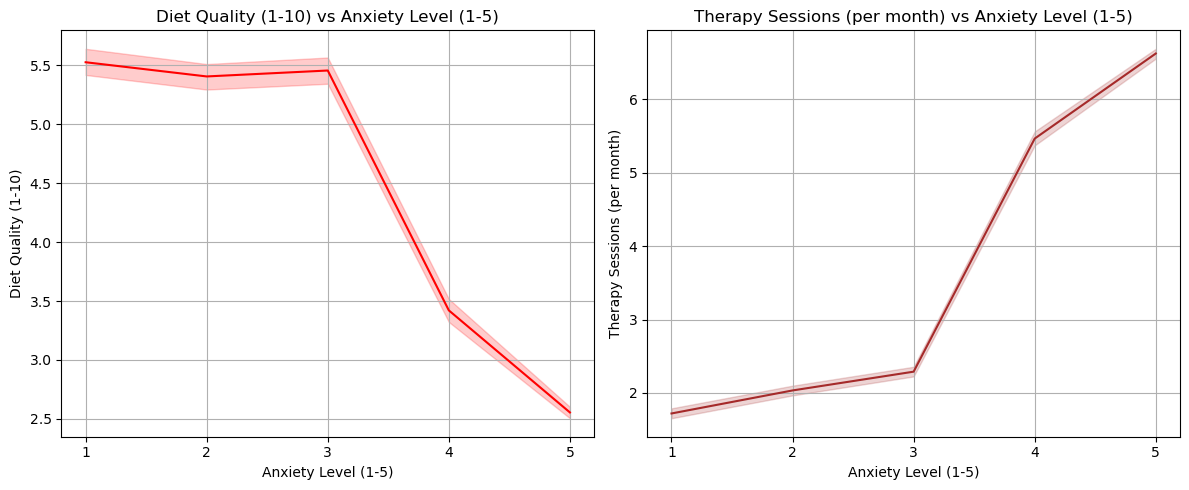

In [25]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.lineplot(y='Diet Quality (1-10)',x="Anxiety Level (1-5)",data=df,ax=axes[0],color='red')
axes[0].set_xticks([1,2,3,4,5])
axes[0].grid(True)
axes[0].set_title("Diet Quality (1-10) vs Anxiety Level (1-5)")

#plot2
sns.lineplot(y="Therapy Sessions (per month)",x="Anxiety Level (1-5)",data=df,ax=axes[1],color="brown")
axes[1].set_xticks([1,2,3,4,5])
axes[1].grid(True)
axes[1].set_title("Therapy Sessions (per month) vs Anxiety Level (1-5)")

plt.tight_layout()
plt.show()

The line graph shows a clear negative relationship between Diet Quality and anxiety levels. For individuals with anxiety levels between 1 and 3, Diet Quality remains relatively stable around 5.5. However, there is a sharp decline at Level 4, where Diet Quality drops to approximately 3.4, and reaches its lowest point at Level 5 (approx. 2.5). This indicates that as anxiety reaches severe levels, individuals may significantly neglect their nutritional habits.

The line graph shows a clear positive relationship between Therapy Sessions and anxiety levels.For individuals with anxiety levels between 1 and 3,Therapy Sessions remain relatively flat (around 2 sessions). At Level 4 there is a sudden spike which increases the therapy sessions from average 3.2 to 5.5. for Level 5 it increased to average 6 or more session.This suggests that as anxiety levels become severe, individuals are significantly more likely to engage in professional therapy.

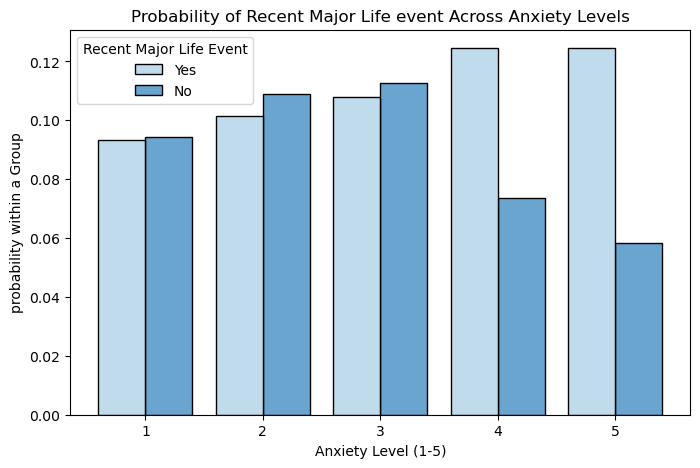

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Anxiety Level (1-5)",hue='Recent Major Life Event',
             multiple="dodge",palette="Blues",stat="probability",shrink=0.8,discrete=True)
plt.xticks([1,2,3,4,5])
plt.ylabel("probability within a Group")
plt.title("Probability of Recent Major Life event Across Anxiety Levels")
plt.show()

From graph as for Anxiety level from 1 to 3. The percentage of Individuals who experienced Recent Major Life event is lower than those who have not experienced. but for higher anxiety levels (4 and 5) Individuals experienced Recent Major Life event are more than those who did not experience and there is significant difference between "Yes" and "No" group.

## encoding

In [27]:
df.drop(columns=["Gender"],axis=1,inplace=True)

In [28]:
df['Family History of Anxiety']=df['Family History of Anxiety'].map({'Yes':1,'No':0})
df['Dizziness']=df['Dizziness'].map({'Yes':1,'No':0})
df['Medication']=df['Medication'].map({'Yes':1,'No':0})
df['Recent Major Life Event']=df['Recent Major Life Event'].map({'Yes':1,'No':0})
df['Smoking']=df['Smoking'].map({'Yes':1,'No':0})

In [29]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder()
encoded=encoder.fit_transform(df[["Occupation"]]).toarray()
encoded_df=pd.DataFrame(encoded,columns=encoder.get_feature_names_out())
df=pd.concat([df.drop('Occupation',axis=1),encoded_df],axis=1)

In [30]:
x=df.drop('Anxiety Level (1-5)',axis=1)
y=df['Anxiety Level (1-5)']

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
scale=StandardScaler()

In [35]:
x_numeric=['Age', 'Sleep Hours', 'Physical Activity (hrs/week)',
       'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)','Stress Level (1-10)',
       'Heart Rate (bpm)', 'Breathing Rate (breaths/min)',
       'Sweating Level (1-5)','Therapy Sessions (per month)','Diet Quality (1-10)']

In [36]:
x_train[x_numeric]=scale.fit_transform(x_train[x_numeric])
x_test[x_numeric]=scale.transform(x_test[x_numeric])

## Model Training and Evaluation

In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
LR=LogisticRegression()

In [39]:
LR.fit(x_train,y_train)

LogisticRegression()

In [40]:
y_pred=LR.predict(x_test)

In [41]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [42]:
print(accuracy_score(y_test,y_pred))

0.6909312728751525


In [43]:
from sklearn.tree import DecisionTreeClassifier

In [44]:
DTC=DecisionTreeClassifier()

In [45]:
DTC.fit(x_train,y_train)

DecisionTreeClassifier()

In [46]:
y_pred=DTC.predict(x_test)

In [47]:
print(accuracy_score(y_test,y_pred))

0.7246848312322082


In [48]:
from sklearn.ensemble import RandomForestClassifier
RFC=RandomForestClassifier(n_estimators=850)

In [49]:
RFC.fit(x_train,y_train)

RandomForestClassifier(n_estimators=850)

In [50]:
y_pred=RFC.predict(x_test)

In [51]:
print(accuracy_score(y_test,y_pred))

0.8401789345262302


In [52]:
print(confusion_matrix(y_test, y_pred))

[[416  55   7   0   0]
 [ 83 311 131   2   0]
 [  0  59 462   3   0]
 [  0   3   4 433  33]
 [  0   0   0  13 444]]


In [53]:
y_train_xgb = y_train - 1
y_test_xgb  = y_test  - 1

In [54]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.5,
    reg_lambda=2,
    random_state=42)

In [55]:
model.fit(x_train, y_train_xgb)
y_pred_xgb = model.predict(x_test)
print(accuracy_score(y_test_xgb, y_pred_xgb))

0.8373322488816592


## Conclusion & Insights
To get the most accurate results, I tested different machine learning models:Logistic regression,Decision Tree, Random Forest and XGBoost. After comparing their performance, the Random Forest model came out on top with a final accuracy of 84.01%. It was the most reliable at identifying the correct anxiety level for each person.This high accuracy proves that we can successfully predict anxiety levels by looking at a person's lifestyle—like their sleep, diet, and life history. the model is excellent at spotting when someone has reached a severe anxiety level. This shows that data can be a powerful tool for identifying people who need professional support before their symptoms get worse.

## Prediction

In [64]:
age = int(input("Enter your age: "))
sleep_hours = float(input("Enter your sleeping hours: "))
physical_activity = float(input("Enter physical activity (hrs/week): "))
caffeine = int(input("Enter caffeine intake (mg/day): "))
alcohol = int(input("Enter alcohol consumption (drinks/week): "))
smoking = int(input("Do you smoke? (1 = Yes, 0 = No): "))
family_history = int(input(" Do you have Family history of anxiety? (1 = Yes, 0 = No): "))
stress = int(input("Stress level (1-10): "))
heart_rate = int(input("Heart rate (bpm): "))
breathing_rate = int(input("Breathing rate (breaths/min): "))
sweating_level = int(input("Sweating level (1-5): "))
dizziness = int(input("Do you feel dizziness? (1 = Yes, 0 = No): "))
medication = int(input("Are you currently taking any medication? (1 = Yes, 0 = No): "))
therapy = int(input("Therapy sessions/month: "))
life_event=int(input("Have you faced any major recent life event (1 = Yes, 0 = No): "))
diet_quality = int(input("Diet quality (1-10): "))
occupation=input("Enter your occupation").strip().capitalize()

Enter your age:  40
Enter your sleeping hours:  3
Enter physical activity (hrs/week):  0
Enter caffeine intake (mg/day):  600
Enter alcohol consumption (drinks/week):  18
Do you smoke? (1 = Yes, 0 = No):  1
 Do you have Family history of anxiety? (1 = Yes, 0 = No):  1
Stress level (1-10):  9
Heart rate (bpm):  130
Breathing rate (breaths/min):  30
Sweating level (1-5):  4
Do you feel dizziness? (1 = Yes, 0 = No):  1
Are you currently taking any medication? (1 = Yes, 0 = No):  0
Therapy sessions/month:  0
Have you faced any major recent life event (1 = Yes, 0 = No):  1
Diet quality (1-10):  6
Enter your occupation artist


In [65]:
occupations = ["Artist", "Athlete", "Chef",
    "Doctor", "Engineer", "Freelancer",
    "Lawyer", "Musician", "Nurse",
    "Other", "Scientist", "Student", "Teacher"]
if occupation not in occupations:
    occupation = "Other"
occupation_encoded = []
for occ in occupations:
    if occupation == occ:
        occupation_encoded.append(1)
    else:
        occupation_encoded.append(0)

In [66]:
input_list = [
    age, sleep_hours, physical_activity, caffeine, alcohol,
    smoking, family_history, stress, heart_rate, breathing_rate,
    sweating_level, dizziness, medication, therapy,
    life_event, diet_quality
] + occupation_encoded


In [67]:
input_data = np.array([input_list])

In [68]:
input_df = pd.DataFrame(input_data, columns=x_train.columns)

In [69]:
input_df[x_numeric] = scale.transform(input_df[x_numeric])

In [70]:
prediction = RFC.predict(input_df)
print("Prediction:", prediction)

Prediction: [4]


## Final Result & Interpretation
Based on the input provided, the model predicts an Anxiety Levels.

What this means:

Level 1-2: Low/Mild Anxiety. Suggested focus on maintaining current lifestyle and regular sleep.

Level 3: Moderate Anxiety. May indicate a need for better stress management or adjusting physical activity/caffeine intake.

Level 4-5: High Anxiety. It is highly recommended to consult with a healthcare professional or counselor.